# Noise Peaks for Masked/Padded Slots

Goal: replace masked-out peaks and padding slots (previously filled with `0`) with *random noise peaks*:
- random m/z (uniform in `[0, 1]` after normalization)
- random intensity sampled from a Gaussian (implemented as TF `truncated_normal` + clip)

This notebook estimates an *acceptable* Gaussian intensity level from the dataset and provides recommended config values for `input_pipeline.py`.


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))

import glob

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from input_pipeline import _NUM_PEAKS_INPUT, _build_dataset

print('TF:', tf.__version__)


2026-02-19 02:38:12.828873: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-19 02:38:12.860028: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-02-19 02:38:13.729081: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF: 2.19.0


/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- Load raw TFRecord intensities (pre top-k) ---

train_files = sorted(glob.glob('data/gems_peaklist_tfrecord/train/*.tfrecord'))
print('num_train_files:', len(train_files))

feature_spec = {
    'mz': tf.io.FixedLenFeature([_NUM_PEAKS_INPUT], tf.float32),
    'intensity': tf.io.FixedLenFeature([_NUM_PEAKS_INPUT], tf.float32),
    'precursor_mz': tf.io.FixedLenFeature([1], tf.float32),
}

@tf.autograph.experimental.do_not_convert
def _parse_raw_intensity(serialized_batch: tf.Tensor) -> tf.Tensor:
    parsed = tf.io.parse_example(serialized_batch, feature_spec)
    return parsed['intensity']

raw_ds = (
    tf.data.TFRecordDataset(train_files, compression_type='GZIP', buffer_size=250_000)
    .batch(512)
    .map(_parse_raw_intensity, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

raw_intensity = []
for batch in raw_ds.take(200):
    arr = batch.numpy().reshape(-1)
    arr = arr[arr > 0]
    raw_intensity.append(arr)
raw_intensity = np.concatenate(raw_intensity)

print('raw_intensity nonzero count:', raw_intensity.size)
print('raw_intensity min/max:', float(raw_intensity.min()), float(raw_intensity.max()))
print('raw_intensity mean/std:', float(raw_intensity.mean()), float(raw_intensity.std()))


2026-02-19 02:38:15.983543: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


num_train_files: 1


raw_intensity nonzero count: 6072177
raw_intensity min/max: 2.5023178750416264e-05 1.0
raw_intensity mean/std: 0.08094209432601929 0.16753950715065002


2026-02-19 02:38:16.417063: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [3]:
# --- Estimate a Gaussian noise model from low-intensity peaks ---
# We treat very small peaks as "noise-like" and fit a Gaussian on that slice.

thresholds = [1e-4, 5e-4, 1e-3, 2e-3, 5e-3]
noise_stats = {}
for thr in thresholds:
    subset = raw_intensity[raw_intensity <= thr]
    mu = float(subset.mean())
    sigma = float(subset.std())
    noise_stats[thr] = (mu, sigma, int(subset.size))
    print(f"thr={thr:.0e}  n={subset.size:>8}  frac={subset.size/raw_intensity.size:>7.4f}  mean={mu:.6f}  std={sigma:.6f}")

# Recommended: use thr=1e-3 (0.1% relative intensity) as a noise floor proxy.
noise_thr = 1e-3
noise_mu, noise_sigma, _ = noise_stats[noise_thr]
print()
print('Recommended noise Gaussian (from raw peaks <= 1e-3):')
print('  sigreg_noise_intensity_mean =', noise_mu)
print('  sigreg_noise_intensity_std  =', noise_sigma)


thr=1e-04  n=     187  frac= 0.0000  mean=0.000063  std=0.000021
thr=5e-04  n=   19527  frac= 0.0032  mean=0.000372  std=0.000095
thr=1e-03  n=  101501  frac= 0.0167  mean=0.000696  std=0.000207
thr=2e-03  n=  317468  frac= 0.0523  mean=0.001249  std=0.000462
thr=5e-03  n=  938362  frac= 0.1545  mean=0.002710  std=0.001288

Recommended noise Gaussian (from raw peaks <= 1e-3):
  sigreg_noise_intensity_mean = 0.0006960845785215497
  sigreg_noise_intensity_std  = 0.00020668510114774108


In [4]:
# --- Compare to model-consumed (top-k) valid peak intensities ---
# This uses the same parsing + top-k as the training pipeline.

ds = _build_dataset(
    train_files,
    batch_size=256,
    shuffle_buffer=0,
    seed=0,
    drop_remainder=False,
    tfrecord_buffer_size=250_000,
    max_precursor_mz=1000.0,
    include_fingerprint=False,
    min_peak_intensity=1e-4,
    mz_representation='mz',
    include_sigreg_augmentation=False,
    peak_ordering='intensity',
)

valid_intensity = []
for batch in ds.take(200):
    inten = batch['peak_intensity'].numpy()
    valid = batch['peak_valid_mask'].numpy()
    valid_intensity.append(inten[valid])
valid_intensity = np.concatenate(valid_intensity)

qs = [0.001, 0.01, 0.05, 0.1, 0.5, 0.9, 0.95]
print('valid_intensity count:', valid_intensity.size)
for q in qs:
    print(f"q={q:>6}: {float(np.quantile(valid_intensity, q)):.6f}")

print()
print('Noise (mu±2σ) vs valid intensity quantiles:')
print('  noise_mu - 2*noise_sigma =', noise_mu - 2*noise_sigma)
print('  noise_mu + 2*noise_sigma =', noise_mu + 2*noise_sigma)


valid_intensity count: 2113341
q= 0.001: 0.000391
q=  0.01: 0.000975
q=  0.05: 0.002688
q=   0.1: 0.004640
q=   0.5: 0.031587
q=   0.9: 0.224356
q=  0.95: 0.411084

Noise (mu±2σ) vs valid intensity quantiles:
  noise_mu - 2*noise_sigma = 0.00028271437622606754
  noise_mu + 2*noise_sigma = 0.0011094547808170319


2026-02-19 02:38:17.449253: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


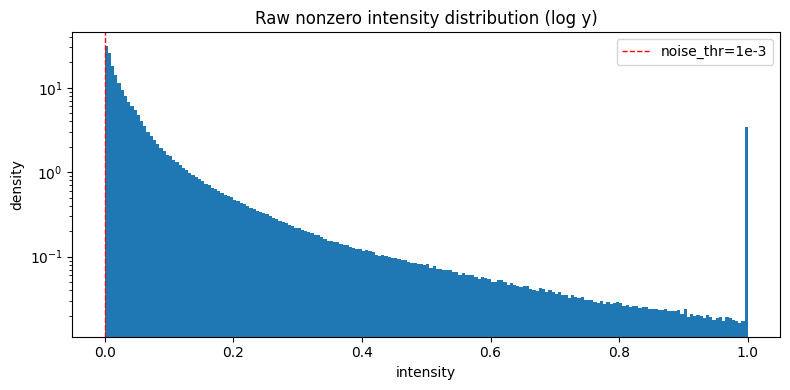

In [5]:
# --- Visual sanity check: histogram (log-scale) ---

plt.figure(figsize=(8, 4))
plt.hist(raw_intensity, bins=200, density=True)
plt.yscale('log')
plt.title('Raw nonzero intensity distribution (log y)')
plt.xlabel('intensity')
plt.ylabel('density')
plt.axvline(noise_thr, color='red', linestyle='--', linewidth=1, label='noise_thr=1e-3')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
# --- Simulate the noise sampler used in input_pipeline.py ---
# We use TF truncated_normal (±2σ) + clip to [0,1].

n = 200_000
noise = tf.random.truncated_normal([n], mean=noise_mu, stddev=noise_sigma, dtype=tf.float32)
noise = tf.clip_by_value(noise, 0.0, 1.0).numpy()

print('sim noise min/max:', float(noise.min()), float(noise.max()))
print('sim noise mean/std:', float(noise.mean()), float(noise.std()))
for q in [0.5, 0.9, 0.99, 0.999]:
    print(f"sim noise q={q}: {float(np.quantile(noise, q)):.6f}")


sim noise min/max: 0.0002827516000252217 0.0011094545479863882
sim noise mean/std: 0.0006962643237784505 0.0001816517615225166
sim noise q=0.5: 0.000696
sim noise q=0.9: 0.000941
sim noise q=0.99: 0.001078
sim noise q=0.999: 0.001106


## Recommended config

Use these in your experiment configs:

```python
cfg.sigreg_fill_invalid_with_noise = True
cfg.sigreg_noise_intensity_mean = 7e-4
cfg.sigreg_noise_intensity_std = 2e-4
```

`input_pipeline.py` applies this noise to **masked-out peaks** (View-1) and **padding slots** (both views) by filling invalid slots with random m/z + intensity noise, while keeping `fused_valid_mask` unchanged.
